In [1]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def extract_placeable_area_multicolor(image_path, mask_path, k_clusters=5, min_brightness=40):
    """
    Extracts placeable regions from multi-colored rooftops (e.g., White AND Red in same image).
    
    Args:
        min_brightness (int): Threshold (0-255) to reject shadows. 
                              Clusters darker than this are considered non-placeable.
    """
    # 1. Load Data
    img = cv2.imread(image_path)
    if img is None: return None, None, None
    
    # --- FIX 1: Gamma Correction (Brighten Dark Images) ---
    # This helps distinguish "Dark Brown Roof" from "Black Shadow"
    gamma = 1.5 
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, 1.0 / gamma) * 255.0, 0, 255)
    img_bright = cv2.LUT(img, lookUpTable)
    
    img_rgb = cv2.cvtColor(img_bright, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bright, cv2.COLOR_BGR2HSV) # HSV is better for brightness checking
    
    # Load Mask
    rooftop_mask = cv2.imread(mask_path, 0)
    if rooftop_mask is None: return None, None, None
    if np.max(rooftop_mask) == 1: rooftop_mask = rooftop_mask * 255
    _, rooftop_mask = cv2.threshold(rooftop_mask, 0, 255, cv2.THRESH_BINARY)

    # 2. Texture Analysis (Dynamic Edge Detection)
    # Using dynamic thresholds to handle both bright white and dark brick roofs
    gray = cv2.cvtColor(img_bright, cv2.COLOR_BGR2GRAY)
    v_median = np.median(gray)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v_median))
    upper = int(min(255, (1.0 + sigma) * v_median))
    
    edges = cv2.Canny(gray, lower, upper)
    
    # Dilate edges (remove grid lines/vents)
    kernel = np.ones((3,3), np.uint8)
    dilated_edges = cv2.dilate(edges, kernel, iterations=2)
    smoothness_mask = cv2.bitwise_not(dilated_edges)
    smooth_roof = cv2.bitwise_and(smoothness_mask, smoothness_mask, mask=rooftop_mask)

    # 3. Multi-Color Clustering
    valid_pixels = img_rgb[rooftop_mask > 0]
    
    if len(valid_pixels) == 0:
        return None, None, rooftop_mask

    # We use more clusters (k=5) to capture White, Red, Brown, Dark Shadow, Light Shadow separately
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(valid_pixels)
    
    # --- FIX 2: Smart Cluster Selection ---
    # Instead of picking 1 dominant cluster, we check EACH cluster.
    # If a cluster is bright enough (not shadow), we keep it.
    
    # Reconstruct the mask logic
    color_mask = np.zeros_like(rooftop_mask)
    coords = np.column_stack(np.where(rooftop_mask > 0))
    
    # Get the average brightness (V channel) for each cluster label
    cluster_brightness = {}
    valid_hsv_pixels = img_hsv[rooftop_mask > 0] # Get V values for valid area
    
    for i in range(k_clusters):
        # Extract pixels belonging to cluster 'i'
        cluster_mask = (labels == i)
        if np.sum(cluster_mask) == 0: continue
        
        # Calculate mean Brightness (Value) of this cluster
        # HSV channel 2 is Value (Brightness)
        pixels_in_cluster = valid_hsv_pixels[cluster_mask]
        avg_v = np.mean(pixels_in_cluster[:, 2]) 
        
        cluster_brightness[i] = avg_v

    # Select valid clusters
    valid_labels = []
    print("Debug Cluster Brightness:")
    for label, brightness in cluster_brightness.items():
        print(f"  Cluster {label}: Avg Brightness = {brightness:.2f}")
        # If brightness > threshold, it's a valid roof part (White, Red, Brown)
        # If brightness < threshold, it's likely a shadow or deep gap
        if brightness > min_brightness:
            valid_labels.append(label)
            
    # Rebuild mask with ALL valid labels
    for (r, c), label in zip(coords, labels):
        if label in valid_labels:
            color_mask[r, c] = 255

    # 4. Combine & Clean Up
    combined_raw = cv2.bitwise_and(color_mask, smooth_roof)
    
    # Morphological Closing to connect brick patterns
    clean_mask = cv2.morphologyEx(combined_raw, cv2.MORPH_CLOSE, kernel, iterations=3)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # 5. Visualization
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy() # Show on original, not brightened
    vis[clean_mask > 0] = [0, 255, 0]
    
    return clean_mask, vis, rooftop_mask

# --- NEW: SOLAR PANEL PLACEMENT ALGORITHM ---
def place_panels(img, placeable_mask, panel_w, panel_h, gap=2):
    """
    Scans the mask and fits the maximum number of panels in a grid.
    """
    height, width = placeable_mask.shape
    
    # Create a canvas for visualization
    placement_vis = img.copy()
    total_panels = 0
    
    # We scan the grid. 
    # Step size = panel_dimension + gap
    step_y = panel_h + gap
    step_x = panel_w + gap
    
    for y in range(0, height, step_y):
        for x in range(0, width, step_x):
            # Define the panel coordinates
            y2 = y + panel_h
            x2 = x + panel_w
            
            # Boundary check
            if y2 >= height or x2 >= width:
                continue
                
            # extract the region of interest (ROI) from the placeable mask
            roi = placeable_mask[y:y2, x:x2]
            
            # CHECK: Is this entire region "placeable"?
            # We check if the ROI is fully white (255)
            # We allow a tiny tolerance (e.g. 95% of pixels must be valid) to handle edge noise
            area_pixels = panel_w * panel_h
            valid_pixels = cv2.countNonZero(roi)
            
            if valid_pixels > (0.95 * area_pixels):
                # Valid Spot! Place a panel.
                total_panels += 1
                
                # Draw the panel (Blue Rectangle)
                cv2.rectangle(placement_vis, (x, y), (x2, y2), (255, 0, 0), 1)
                
                # Draw the inner cell (Solar look)
                cv2.rectangle(placement_vis, (x+1, y+1), (x2-1, y2-1), (100, 0, 0), -1)

    return total_panels, placement_vis

def optimize_panel_placement(img_path, placeable_mask, panel_dims, gap=2):
    """
    Tries both Portrait and Landscape orientations and picks the best one.
    panel_dims: tuple (width_px, length_px) e.g., (7, 14)
    """
    original_img = cv2.imread(img_path)
    w, l = int(panel_dims[0]), int(panel_dims[1])
    
    print(f"Attempting placement with Box: {w}x{l} and Gap: {gap}")

    # Strategy 1: Portrait (Width x Length)
    count1, vis1 = place_panels(original_img, placeable_mask, w, l, gap)
    
    # Strategy 2: Landscape (Length x Width) - Swap W and L
    count2, vis2 = place_panels(original_img, placeable_mask, l, w, gap)
    
    print(f"  Orientation 1 (Portrait): {count1} panels")
    print(f"  Orientation 2 (Landscape): {count2} panels")
    
    if count1 >= count2:
        print(f"-> Selected Portrait ({count1} panels)")
        return count1, vis1
    else:
        print(f"-> Selected Landscape ({count2} panels)")
        return count2, vis2


Debug Cluster Brightness:
  Cluster 0: Avg Brightness = 237.68
  Cluster 1: Avg Brightness = 134.95
  Cluster 2: Avg Brightness = 197.94
  Cluster 3: Avg Brightness = 90.10
  Cluster 4: Avg Brightness = 164.81
Attempting placement with Box: 7x14 and Gap: 2
  Orientation 1 (Portrait): 204 panels
  Orientation 2 (Landscape): 204 panels
-> Selected Portrait (204 panels)


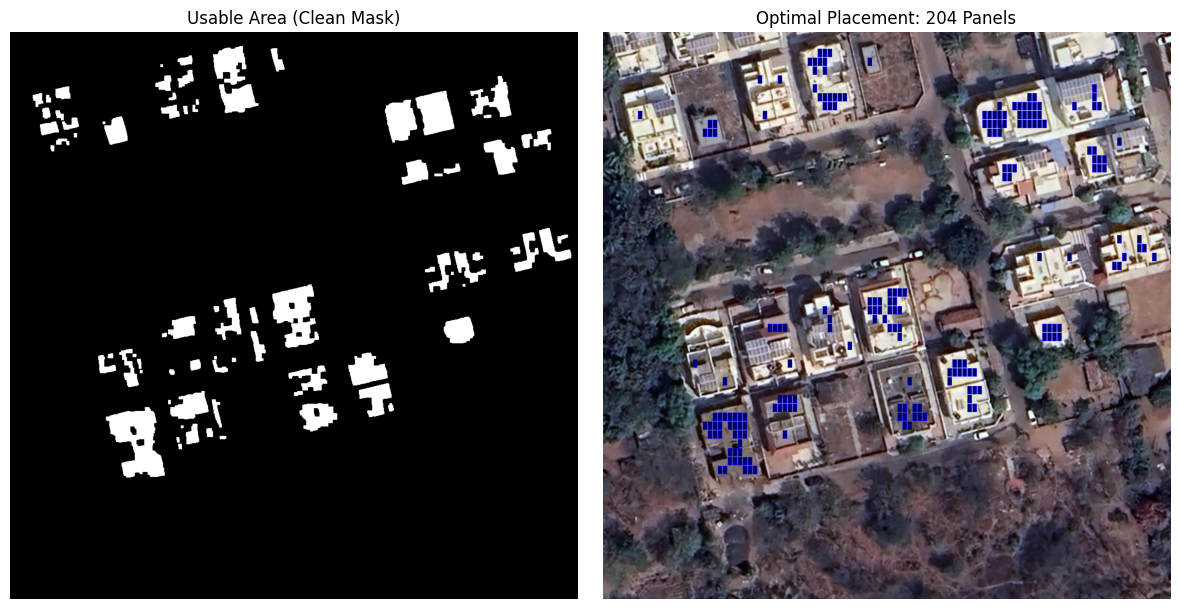


Final Result: Estimated 204 panels can be installed.


In [2]:
# --- UPDATED USAGE ---

# 1. Run your existing extraction
image_path = '../dataset/ghandinagar_dataset/train/sample_0_jpg.rf.4e644d9a9813cce20ae1206c171d2154.jpg'
mask_path = '../dataset/ghandinagar_dataset/train/sample_0_jpg.rf.4e644d9a9813cce20ae1206c171d2154_mask.png'

# Using your code to get the 'clean_mask'
clean_mask, _, _ = extract_placeable_area_multicolor(image_path, mask_path, k_clusters=5, min_brightness=40)

if clean_mask is not None:
    # 2. Define Dimensions from your LabelMe analysis
    # You found: 14.32 px x 7.23 px. We round to nearest integer for pixel grid.
    panel_width_px = 7 
    panel_length_px = 14
    
    # 3. Run Optimization
    # gap=2 pixels ensures they aren't "too packed"
    total_panels, final_vis = optimize_panel_placement(
        image_path, 
        clean_mask, 
        (panel_width_px, panel_length_px), 
        gap=2
    )
    
    # 4. Visualization
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(clean_mask, cmap='gray')
    plt.title("Usable Area (Clean Mask)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Convert BGR to RGB for matplotlib
    plt.imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Optimal Placement: {total_panels} Panels")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Result: Estimated {total_panels} panels can be installed.")
else:
    print("Could not extract placeable area.")

Debug Cluster Brightness:
  Cluster 0: Avg Brightness = 239.27
  Cluster 1: Avg Brightness = 136.86
  Cluster 2: Avg Brightness = 176.30
  Cluster 3: Avg Brightness = 87.32
  Cluster 4: Avg Brightness = 209.69
Attempting placement with Box: 7x14 and Gap: 1
  Orientation 1 (Portrait): 300 panels
  Orientation 2 (Landscape): 309 panels
-> Selected Landscape (309 panels)


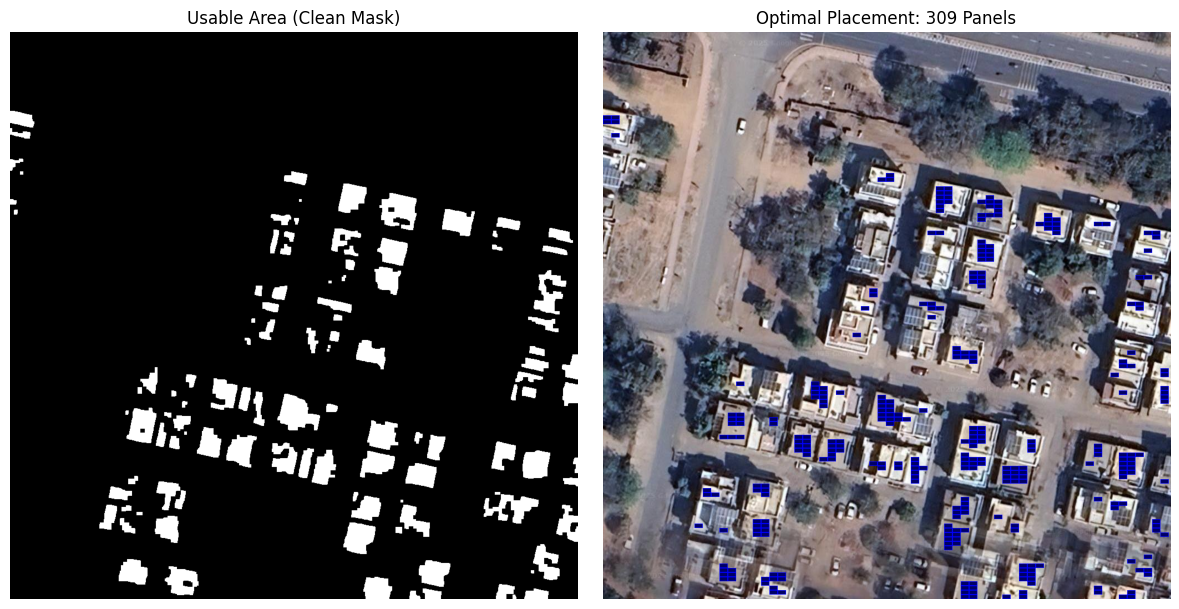


Final Result: Estimated 309 panels can be installed.


In [4]:
# --- UPDATED USAGE ---

# 1. Run your existing extraction
image_path = '../dataset/ghandinagar_dataset/train/sample_0_jpg.rf.b07b5f8bd2730e77c4b81d3a6c078430.jpg'
mask_path = '../dataset/ghandinagar_dataset/train/sample_0_jpg.rf.b07b5f8bd2730e77c4b81d3a6c078430_mask.png'

# Using your code to get the 'clean_mask'
clean_mask, _, _ = extract_placeable_area_multicolor(image_path, mask_path, k_clusters=5, min_brightness=40)

if clean_mask is not None:
    # 2. Define Dimensions from your LabelMe analysis
    # You found: 14.32 px x 7.23 px. We round to nearest integer for pixel grid.
    panel_width_px = 7 
    panel_length_px = 14
    
    # 3. Run Optimization
    # gap=2 pixels ensures they aren't "too packed"
    total_panels, final_vis = optimize_panel_placement(
        image_path, 
        clean_mask, 
        (panel_width_px, panel_length_px), 
        gap=1
    )
    
    # 4. Visualization
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(clean_mask, cmap='gray')
    plt.title("Usable Area (Clean Mask)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Convert BGR to RGB for matplotlib
    plt.imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Optimal Placement: {total_panels} Panels")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Result: Estimated {total_panels} panels can be installed.")
else:
    print("Could not extract placeable area.")

In [1]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import math

# ==========================================
# 1. CONFIGURATION & METADATA
# ==========================================

# Database of Ground Sampling Distances (GSD) in meters/pixel
DATASET_GSD = {
    "AIRS": 0.075,      # 7.5 cm/pixel
    "NACALA": 0.05,     # ~5 cm/pixel (High Res Drone)
    "INRIA": 0.30,      # 30 cm/pixel (Satellite)
    "WHU_AERIAL": 0.075,# 7.5 cm/pixel (Original)
    "WHU_RASTER": 0.30  # 30 cm/pixel (Downsampled version)
}

# Standard Residential Panel Dimensions (Real World Meters)
# Format: (Length_meters, Width_meters)
REAL_PANEL_DIMS = (1.7, 1.0) 

# Required Gap between panels (clamps/spacing) in meters
REAL_GAP_METER = 0.02  # 2 cm

# ==========================================
# 2. HELPER: DYNAMIC SCALING
# ==========================================
def get_pixel_dimensions(dataset_name, real_dims, real_gap):
    """
    Converts real-world meters to image pixels based on dataset GSD.
    """
    if dataset_name not in DATASET_GSD:
        raise ValueError(f"Dataset {dataset_name} not found. Available: {list(DATASET_GSD.keys())}")
    
    gsd = DATASET_GSD[dataset_name]
    
    # Calculate pixels (Meters / GSD)
    # We use ceil/round to ensure we don't underestimate space required
    length_px = round(real_dims[0] / gsd)
    width_px = round(real_dims[1] / gsd)
    gap_px = max(1, round(real_gap / gsd)) # Minimum 1 pixel gap for visualization
    
    print(f"\n[INFO] Dataset: {dataset_name} (GSD: {gsd} m/px)")
    print(f"[INFO] Real Panel: {real_dims[0]}m x {real_dims[1]}m")
    print(f"[INFO] Pixel Panel: {length_px}px x {width_px}px (Gap: {gap_px}px)")
    
    return (length_px, width_px), gap_px

# ==========================================
# 3. SEGMENTATION LOGIC (Your Existing Code)
# ==========================================
def extract_placeable_area_multicolor(image_path, mask_path, k_clusters=5, min_brightness=40):
    """
    Extracts usable rooftop area by removing shadows and obstacles.
    """
    img = cv2.imread(image_path)
    if img is None: 
        print(f"Error: Could not load image at {image_path}")
        return None, None, None
    
    # --- Gamma Correction ---
    gamma = 1.5 
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, 1.0 / gamma) * 255.0, 0, 255)
    img_bright = cv2.LUT(img, lookUpTable)
    
    img_rgb = cv2.cvtColor(img_bright, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bright, cv2.COLOR_BGR2HSV)
    
    rooftop_mask = cv2.imread(mask_path, 0)
    if rooftop_mask is None: 
        print(f"Error: Could not load mask at {mask_path}")
        return None, None, None
        
    _, rooftop_mask = cv2.threshold(rooftop_mask, 127, 255, cv2.THRESH_BINARY)

    # --- Texture Analysis ---
    gray = cv2.cvtColor(img_bright, cv2.COLOR_BGR2GRAY)
    v_median = np.median(gray)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v_median))
    upper = int(min(255, (1.0 + sigma) * v_median))
    edges = cv2.Canny(gray, lower, upper)
    
    kernel = np.ones((3,3), np.uint8)
    dilated_edges = cv2.dilate(edges, kernel, iterations=2)
    smoothness_mask = cv2.bitwise_not(dilated_edges)
    smooth_roof = cv2.bitwise_and(smoothness_mask, smoothness_mask, mask=rooftop_mask)

    # --- Clustering ---
    valid_pixels = img_rgb[rooftop_mask > 0]
    if len(valid_pixels) == 0: return None, None, rooftop_mask

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(valid_pixels)
    
    color_mask = np.zeros_like(rooftop_mask)
    coords = np.column_stack(np.where(rooftop_mask > 0))
    
    # Check brightness of each cluster
    valid_hsv_pixels = img_hsv[rooftop_mask > 0]
    cluster_brightness = {}
    
    for i in range(k_clusters):
        cluster_mask = (labels == i)
        if np.sum(cluster_mask) == 0: continue
        pixels_in_cluster = valid_hsv_pixels[cluster_mask]
        avg_v = np.mean(pixels_in_cluster[:, 2]) 
        cluster_brightness[i] = avg_v

    valid_labels = [label for label, b in cluster_brightness.items() if b > min_brightness]
            
    for (r, c), label in zip(coords, labels):
        if label in valid_labels:
            color_mask[r, c] = 255

    # --- Clean Up ---
    combined_raw = cv2.bitwise_and(color_mask, smooth_roof)
    clean_mask = cv2.morphologyEx(combined_raw, cv2.MORPH_CLOSE, kernel, iterations=3)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    vis[clean_mask > 0] = [0, 255, 0]
    
    return clean_mask, vis, img

# ==========================================
# 4. PLACEMENT LOGIC
# ==========================================
def place_panels(img, placeable_mask, panel_w, panel_h, gap):
    height, width = placeable_mask.shape
    placement_vis = img.copy()
    total_panels = 0
    
    step_y = panel_h + gap
    step_x = panel_w + gap
    
    for y in range(0, height, step_y):
        for x in range(0, width, step_x):
            y2 = y + panel_h
            x2 = x + panel_w
            
            if y2 >= height or x2 >= width: continue
            
            roi = placeable_mask[y:y2, x:x2]
            area_pixels = panel_w * panel_h
            valid_pixels = cv2.countNonZero(roi)
            
            # Tolerance: 90% of the panel area must be on valid roof
            if valid_pixels > (0.90 * area_pixels):
                total_panels += 1
                # Draw Panel (Blue)
                cv2.rectangle(placement_vis, (x, y), (x2, y2), (255, 0, 0), 1)
                # Draw Cell (Dark Blue)
                if panel_w > 2 and panel_h > 2: # Only draw inner detail if large enough
                    cv2.rectangle(placement_vis, (x+1, y+1), (x2-1, y2-1), (100, 0, 0), -1)
                else:
                    cv2.rectangle(placement_vis, (x, y), (x2, y2), (100, 0, 0), -1)

    return total_panels, placement_vis

def optimize_panel_placement(img, placeable_mask, dataset_name):
    """
    Wrapper that handles the dynamic sizing and orientation check.
    """
    # 1. Calculate Pixel Dimensions dynamically
    (p_len_px, p_wid_px), gap_px = get_pixel_dimensions(dataset_name, REAL_PANEL_DIMS, REAL_GAP_METER)
    
    if p_len_px == 0 or p_wid_px == 0:
        print("[WARNING] Image resolution is too low for this panel size. Panels would be 0 pixels.")
        return 0, img

    # 2. Try Portrait (L x W)
    count1, vis1 = place_panels(img, placeable_mask, p_wid_px, p_len_px, gap_px)
    
    # 3. Try Landscape (W x L)
    count2, vis2 = place_panels(img, placeable_mask, p_len_px, p_wid_px, gap_px)
    
    print(f"  Portrait count: {count1}")
    print(f"  Landscape count: {count2}")
    
    if count1 >= count2:
        return count1, vis1
    else:
        return count2, vis2



In [ ]:
# ==========================================
# 5. MAIN EXECUTION
# ==========================================

# INPUTS
IMAGE_PATH = '../dataset/whu-building-sample/images/10001011.TIF'
MASK_PATH = '../dataset/whu-building-sample/labels/10001011.tif'

# SELECT YOUR DATASET HERE: "AIRS", "NACALA", "INRIA", "WHU_AERIAL"
SELECTED_DATASET = "WHU_RASTER" 

# Run Extraction
clean_mask, _, original_img = extract_placeable_area_multicolor(IMAGE_PATH, MASK_PATH)

if clean_mask is not None:
    # Run Optimization (Dimensions are calculated inside based on SELECTED_DATASET)
    total_panels, final_vis = optimize_panel_placement(original_img, clean_mask, SELECTED_DATASET)

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(clean_mask, cmap='gray')
    plt.title(f"Usable Area ({SELECTED_DATASET})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Placed: {total_panels} Panels")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    # Calculate Energy Potential (Estimate: 400W per panel)
    kw_capacity = (total_panels * 400) / 1000
    print(f"\n--- RESULTS FOR {SELECTED_DATASET} ---")
    print(f"Total Panels: {total_panels}")
    print(f"Estimated Capacity: {kw_capacity} kW")

else:
    print("Failed to extract mask.")


[INFO] Dataset: WHU_RASTER (GSD: 0.3 m/px)
[INFO] Real Panel: 1.7m x 1.0m
[INFO] Pixel Panel: 6px x 3px (Gap: 1px)
  Portrait count: 6996
  Landscape count: 7113


Detected Roof Angle: 9.09 degrees
  Portrait (Slope Adjusted): 2484 panels
  Landscape (Slope Adjusted): 2500 panels


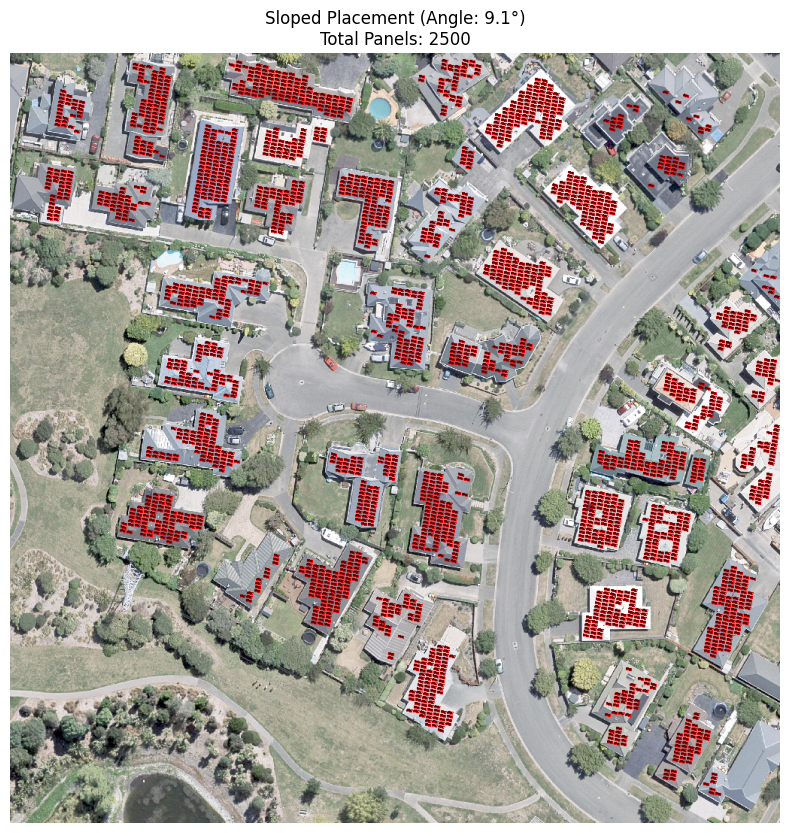

In [4]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import math

# --- 1. PRE-PROCESSING & SEGMENTATION (Kept mostly same, added robust edge return) ---
def extract_placeable_area_multicolor(image_path, mask_path, k_clusters=5, min_brightness=40):
    """
    Extracts placeable regions and returns the edges for orientation detection.
    """
    img = cv2.imread(image_path)
    if img is None: return None, None, None, None
    
    # Gamma Correction
    gamma = 1.5 
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, 1.0 / gamma) * 255.0, 0, 255)
    img_bright = cv2.LUT(img, lookUpTable)
    
    img_rgb = cv2.cvtColor(img_bright, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bright, cv2.COLOR_BGR2HSV)
    
    rooftop_mask = cv2.imread(mask_path, 0)
    if rooftop_mask is None: return None, None, None, None
    if np.max(rooftop_mask) <= 1: rooftop_mask = rooftop_mask * 255
    _, rooftop_mask = cv2.threshold(rooftop_mask, 127, 255, cv2.THRESH_BINARY)

    # Texture Analysis (Edges)
    gray = cv2.cvtColor(img_bright, cv2.COLOR_BGR2GRAY)
    v_median = np.median(gray)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v_median))
    upper = int(min(255, (1.0 + sigma) * v_median))
    
    edges = cv2.Canny(gray, lower, upper)
    
    # Save edges specifically for orientation detection later
    orientation_edges = edges.copy() 

    # Dilate edges for exclusion mask
    kernel = np.ones((3,3), np.uint8)
    dilated_edges = cv2.dilate(edges, kernel, iterations=2)
    smoothness_mask = cv2.bitwise_not(dilated_edges)
    smooth_roof = cv2.bitwise_and(smoothness_mask, smoothness_mask, mask=rooftop_mask)

    # Clustering
    valid_pixels = img_rgb[rooftop_mask > 0]
    if len(valid_pixels) == 0: return None, None, None, None

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(valid_pixels)
    
    color_mask = np.zeros_like(rooftop_mask)
    coords = np.column_stack(np.where(rooftop_mask > 0))
    
    cluster_brightness = {}
    valid_hsv_pixels = img_hsv[rooftop_mask > 0]
    
    for i in range(k_clusters):
        cluster_mask = (labels == i)
        if np.sum(cluster_mask) == 0: continue
        pixels_in_cluster = valid_hsv_pixels[cluster_mask]
        avg_v = np.mean(pixels_in_cluster[:, 2]) 
        cluster_brightness[i] = avg_v

    valid_labels = []
    for label, brightness in cluster_brightness.items():
        if brightness > min_brightness:
            valid_labels.append(label)
            
    for (r, c), label in zip(coords, labels):
        if label in valid_labels:
            color_mask[r, c] = 255

    combined_raw = cv2.bitwise_and(color_mask, smooth_roof)
    clean_mask = cv2.morphologyEx(combined_raw, cv2.MORPH_CLOSE, kernel, iterations=3)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    return clean_mask, img_rgb, rooftop_mask, orientation_edges

# --- 2. ORIENTATION DETECTION ---
def get_dominant_angle(edges_img, roi_mask):
    """
    Uses Hough Transform to find the dominant angle of the roof structure.
    Returns angle in degrees.
    """
    # Only look at edges INSIDE the rooftop area
    masked_edges = cv2.bitwise_and(edges_img, edges_img, mask=roi_mask)
    
    # Hough Lines Probabilistic
    lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, threshold=30, minLineLength=20, maxLineGap=10)
    
    if lines is None:
        return 0.0 # Default to 0 if no lines found
        
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Calculate angle in degrees
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        # Normalize to -90 to 90 range (we just want alignment, direction doesn't matter)
        if angle < -45: angle += 90
        if angle > 45: angle -= 90
        angles.append(angle)
    
    # Return the median angle (robust to outliers)
    if not angles: return 0.0
    
    # Histogram binning could be better, but median is solid for roofs
    dominant_angle = np.median(angles)
    return dominant_angle

def rotate_image(image, angle):
    """Rotates an image around its center."""
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_NEAREST)
    return result, rot_mat

def inverse_rotate_points(points, rot_mat):
    """Rotates points back to original coordinate system."""
    # Add column of ones for affine multiplication
    ones = np.ones(shape=(len(points), 1))
    points_ones = np.hstack([points, ones])
    
    # Invert the rotation matrix
    inverse_rot_mat = cv2.invertAffineTransform(rot_mat)
    
    # Transform
    transformed_points = inverse_rot_mat.dot(points_ones.T).T
    return transformed_points.astype(int)

# --- 3. SLOPED PANEL PLACEMENT ---
def place_panels_on_slope(img, placeable_mask, panel_w, panel_h, angle, gap=2):
    """
    1. Rotates the mask by -angle (to make roof horizontal).
    2. Places panels in a straight grid.
    3. Rotates the panel coordinates back by +angle.
    4. Draws on original image.
    """
    height, width = placeable_mask.shape
    
    # 1. Rotate Mask to be "Flat"
    rotated_mask, rot_mat = rotate_image(placeable_mask, angle)
    
    # Create canvas
    placement_vis = img.copy()
    total_panels = 0
    
    # 2. Standard Scan on Rotated Mask
    step_y = panel_h + gap
    step_x = panel_w + gap
    
    valid_panels_polygons = [] # Store coordinates
    
    # Optimizing loop range to cover rotated canvas
    # (Rotation might cut off corners if we stick to h/w, but standard size usually fine)
    for y in range(0, height, step_y):
        for x in range(0, width, step_x):
            y2 = y + panel_h
            x2 = x + panel_w
            
            if y2 >= height or x2 >= width: continue
            
            # Check ROI on the ROTATED mask
            roi = rotated_mask[y:y2, x:x2]
            area_pixels = panel_w * panel_h
            valid_pixels = cv2.countNonZero(roi)
            
            # Allow slight tolerance
            if valid_pixels > (0.90 * area_pixels):
                total_panels += 1
                
                # Get 4 corners of the panel
                # Order: Top-Left, Top-Right, Bot-Right, Bot-Left
                pts = np.array([
                    [x, y], 
                    [x2, y], 
                    [x2, y2], 
                    [x, y2]
                ], dtype=np.float32)
                
                valid_panels_polygons.append(pts)

    # 3. Rotate Coordinates Back & Draw
    for pts in valid_panels_polygons:
        # Inverse transform the points
        original_pts = inverse_rotate_points(pts, rot_mat)
        
        # Draw rotated rectangle (Panel)
        cv2.polylines(placement_vis, [original_pts], isClosed=True, color=(255, 0, 0), thickness=1)
        
        # Draw inner cell (just for look)
        # Simple centroid-based shrink for inner rectangle
        center = np.mean(original_pts, axis=0)
        inner_pts = (original_pts - center) * 0.8 + center
        cv2.fillPoly(placement_vis, [inner_pts.astype(int)], color=(100, 0, 0))

    return total_panels, placement_vis

# --- 4. OPTIMIZER WRAPPER ---
def optimize_sloped_placement(image_path, mask_path, panel_dims, gap=2):
    # 1. Extract Mask & Edges
    placeable_mask, vis_img, debug_mask, edges = extract_placeable_area_multicolor(image_path, mask_path)
    
    if placeable_mask is None:
        print("No placeable area found.")
        return 0, None

    # 2. Detect Slope
    angle = get_dominant_angle(edges, debug_mask)
    print(f"Detected Roof Angle: {angle:.2f} degrees")
    
    w, l = int(panel_dims[0]), int(panel_dims[1])
    
    # 3. Try Orientations (Portrait vs Landscape) considering the slope
    
    # Strategy 1: Portrait aligned with slope
    count1, vis1 = place_panels_on_slope(vis_img, placeable_mask, w, l, angle, gap)
    
    # Strategy 2: Landscape aligned with slope
    count2, vis2 = place_panels_on_slope(vis_img, placeable_mask, l, w, angle, gap)
    
    print(f"  Portrait (Slope Adjusted): {count1} panels")
    print(f"  Landscape (Slope Adjusted): {count2} panels")
    
    best_vis = vis1 if count1 >= count2 else vis2
    best_count = max(count1, count2)
    
    return best_count, best_vis, angle

# --- USAGE ---
if __name__ == "__main__":
    # Update paths
    IMG_PATH = "../dataset/whu-building-sample/images/100098.TIF"
    MASK_PATH = "../dataset/whu-building-sample/labels/100098.tif"
    
    # Panel size in pixels (depends on your GSD)
    # If GSD = 0.3m/px, a 1m x 2m panel is approx 3px x 7px
    PANEL_DIMS = (3, 7) 
    
    count, result_img, detected_angle = optimize_sloped_placement(IMG_PATH, MASK_PATH, PANEL_DIMS)
    
    if result_img is not None:
        plt.figure(figsize=(10, 10))
        plt.imshow(result_img)
        plt.title(f"Sloped Placement (Angle: {detected_angle:.1f}°)\nTotal Panels: {count}")
        plt.axis('off')
        plt.show()